In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.gridspec import GridSpec
import matplotlib

import sys

sys.path.append("../src")

import jax
import jax.numpy as jnp

import netket as nk
import numpy as np

from netket.operator.spin import sigmax, sigmaz
from metropolis import LocalDoubleFlipRule
from netket.experimental.dynamics import RK45
from callbacks import (
    get_acceptance_rate_callback,
    get_umbrella_monitor_callback,
    get_tdvp_monitor_callback,
    get_parameter_save_callback,
)
from logger import Logger

from schmitt_tdvp_bridge import TDVPSchmittBridge
from schmitt_tdvp import TDVPSchmitt

import argparse
import numpy as np

from gaussian_state import GaussianState
from tfim_exact_majorana import run_ed


W0219 12:27:01.045657 1975694 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0219 12:27:01.048655 1975571 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You must cite NetKet according to our policy. Use nk.cite() to find out how.

In [7]:
import flax.linen as nn
import jax.numpy as jnp
from netket.hilbert import DiscreteHilbert

class AlphaBetaState(nn.Module):
    r"""Tiny Flax model with two scalar trainable parameters (alpha, beta).
    Intended to demonstrate initialization from python floats.
    """
    hilbert: DiscreteHilbert
    alpha0: complex = 0.0
    beta0: complex = 0.0

    @nn.compact
    def __call__(self, x_in):
        """Return a batch of log-psi values."""
        assert self.hilbert.size==1., "Only works for single qubit state"
        alpha = self.param("alpha", nn.initializers.constant(self.alpha0, dtype=complex), ())
        beta = self.param("beta", nn.initializers.constant(self.beta0, dtype=complex), ())
        out = jnp.where(x_in==1, alpha, beta)
        return jnp.log(out).squeeze()
    
hilbert = nk.hilbert.Spin(s=1 / 2, N=1)

def get_vstate(n_samples):
    # Small system because the dense S-matrix scales like O(N_params^2).
    # Increase L/alpha only if you really need the full dense matrix.
    seed = 100

    # Hilbert space: L spin-1/2 sites
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains = n_samples)

    # Model initialized from two python floats -> trainable params start at these values
    model = AlphaBetaState(
        hilbert=hilbert,
        alpha0=1.0,
        beta0=1.0,
    )

    # Variational Monte Carlo state
    vstate = nk.vqs.MCState(
        sampler=sampler,
        model=model,
        n_samples=n_samples,
        seed=seed
    )
    x = vstate.sample(n_samples=n_samples)
    psi = vstate.to_array()
    print(psi)
    return vstate

In [8]:


fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("sigma_z", "Mean"),
    ("sigma_z", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
    ("acceptance_rate", "values")
)

hamiltonian = nk.operator.PauliStringsJax(hilbert, "Y", 1.)
sigma_z = nk.operator.PauliStringsJax(hilbert, "Z", 1.)

def measure_sigma_z(step, log, driver):
    log['sigma_z'] = driver.state.expect(sigma_z)
    return True

In [10]:
from schmitt_tdvp_bridge import TDVPSchmittBridge
from schmitt_tdvp import TDVPSchmitt

def run(q, n_samples_tvmc):

    T = 2.
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"bridge_{n_samples_tvmc}_q_{q:1.2f}"
    # Make sure we always start with the same state in notebook

    vstate = get_vstate(n_samples_tvmc)
    save_path = f"./data/SIGMA_Y/{exp_name}/"
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    logger = Logger(path=save_path, fields=fields_to_track)

    callbacks = [ ]
    callbacks.append(measure_sigma_z)
    callbacks.append(get_parameter_save_callback(save_times, logger))
    # callbacks.append(get_acceptance_rate_callback())
    if q==0:
        tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    else:
        tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
        
    callbacks.append(tdvp_monitor_callback)

    integrator = RK45(1e-3, adaptive=False, rtol=1e-4, dt_limits=(1e-4, 1e-2))
    tvmc_kwargs = {}
    # thermalize
    for i in range(100):
        vstate.sample()
    print(vstate.expect(sigma_z))
    if jnp.isclose(q, 0):
        driver = TDVPSchmitt(
            hamiltonian,
            vstate,
            integrator,
            t0=0,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        driver = TDVPSchmittBridge(
            hamiltonian,
            vstate,
            integrator,
            t0=0,
            q=q,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            diagonal_mels=False,
            **tvmc_kwargs,
        )

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush()
# run(0.0, 2**14)
run(0.8, 2**14)

[0.70710678+0.j 0.70710678+0.j]
   -7.3+0.0j ±  78.1 e-04 [σ²=1.0e+00]


  0%|          | 0.00/2.00 [00:00<?, ?it/s, n=0, Generator=None]

Saved parameters...


  5%|▌         | 0.11/2.00 [00:07<02:02, 65.0s/it, n=109, Generator=0.0000+0.0129j ± 0.0077 [σ²=9.6e-01]]

Saved parameters...


...

 95%|█████████▍| 1.90/2.00 [01:23<00:04, 43.8s/it, n=1899, Generator=-0.0-9.4j ±  66.6 e-04 [σ²=7.3e-01]]  

Saved parameters...


100%|██████████| 2.00/2.00 [01:26<00:00, 43.3s/it, n=2000, Generator=-0.0+2.7j ±   5.7 e-03 [σ²=5.3e-01]]  


Saved parameters...


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 86.588                                                                                                   │
│ ├── (1.8%) | MCState.expect : 1.534 s                                                                           │
│ ├── (9.9%) | MCState.sample : 8.552 s                                                                           │
│ │   └── (43.1%) | sampling n_discarded samples : 3.683 s                                                        │
│ ├── (7.5%) | QGTJacobian_DefaultConstructor : 6.458 s                                                           │
│ │   └── (28.2%) | jacobian : 1.819 s                                                                            │
│ └── (10.9%) | _impl : 9.464 s                                                                                   │
╰───────────────────────────────────────────────────────────────────────

In [10]:
import qutip as qt

# Get the Hamiltonian matrix from netket
H_matrix = hamiltonian.to_sparse()

# Convert to QuTiP Qobj
H_qutip = qt.Qobj(H_matrix)
vstate = get_vstate(2**10)
# Get initial state from vstate
psi0_array = vstate.to_array()
psi0_qutip = qt.Qobj(psi0_array)
psi0_qutip = psi0_qutip.unit()  # Normalize

# Create total magnetization operator (sum of Z_i)
# Convert netket operator to matrix
sigma_z_matrix = sigma_z.to_dense()
# Convert to QuTiP
Z_total_qutip = qt.Qobj(sigma_z_matrix)

# Time evolution parameters
T = 2.
times_exact = np.linspace(0.0, T, 100)

# Evolve the state and calculate expectation values
magnetizations_exact = []
for t in times_exact:
    # Evolve state
    psi_t = (-1j * H_qutip * t).expm() * psi0_qutip
    # Calculate expectation value
    mag = qt.expect(Z_total_qutip, psi_t)
    magnetizations_exact.append(mag)

[0.70710678+0.j 0.70710678+0.j]


Restored: True
Restored: True


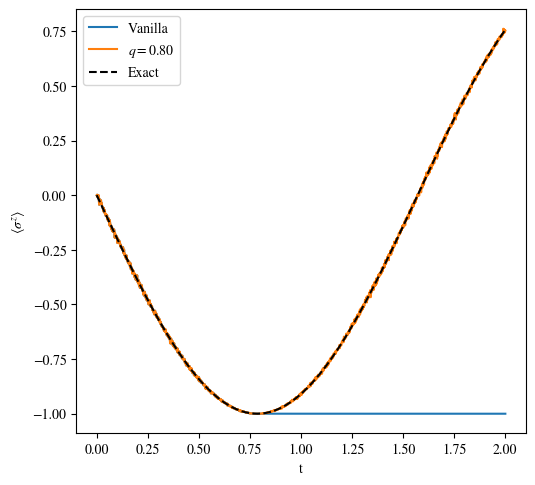

In [11]:
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
n_samples_tvmc = 2**14
fig = plt.figure(figsize=(5.8, 5.5))
gs = GridSpec(1, 1, figure=fig, wspace=0.45, hspace=0.33)
ax_z = fig.add_subplot(gs[0])
for q in [0.0, 0.8]:
    exp_name = f"bridge_{n_samples_tvmc}_q_{q:1.2f}"
    save_path = f"./data/SIGMA_Y/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())

    ax_z.plot(
        logger.data["t"]["values"],
        np.array(logger.data["sigma_z"]["Mean"]).real,
        label="Vanilla" if q == 0 else f"$q=${q:1.2f}",
    )
ax_z.plot(
    times_exact, magnetizations_exact, label="Exact", linestyle="--", color="black"
)
ax_z.set_xlabel("t")
ax_z.set_ylabel(r"$\langle\sigma^z \rangle$")
ax_z.legend()
fig.savefig("Fig4a.pdf")